In [1]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


Dimension du dataset : (29062, 35)

--- Entraînement et enregistrement MLflow : Logistic Regression ---


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/09/29 19:56:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[Logistic Regression] Logged successfully to MLflow (F1-Macro: 0.5732)
🏃 View run Logistic Regression at: http://194.238.26.226:5000/#/experiments/106/runs/265477491d3b4e1a80f697af50ed43d2
🧪 View experiment at: http://194.238.26.226:5000/#/experiments/106

--- Entraînement et enregistrement MLflow : Decision Tree ---


c:\Users\Asus\anaconda3\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/09/29 19:57:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[Decision Tree] Logged successfully to MLflow (F1-Macro: 0.6842)
🏃 View run Decision Tree at: http://194.238.26.226:5000/#/experiments/106/runs/b8e2bded3edd417a89d0124721ff850f
🧪 View experiment at: http://194.238.26.226:5000/#/experiments/106

--- Entraînement et enregistrement MLflow : Random Forest ---


2026/09/29 19:58:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[Random Forest] Logged successfully to MLflow (F1-Macro: 0.7541)
🏃 View run Random Forest at: http://194.238.26.226:5000/#/experiments/106/runs/393cf1f266a44f56842975cfef19f3e5
🧪 View experiment at: http://194.238.26.226:5000/#/experiments/106

=== TABLEAU COMPARATIF DES PERFORMANCES ===


,Modèle,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),F1-Score (Macro)
2,Random Forest,0.994495,0.994327,0.994495,0.994389,0.754098
1,Decision Tree,0.986926,0.990054,0.986926,0.988176,0.684198
0,Logistic Regression,0.951660,0.974987,0.951660,0.961430,0.573192


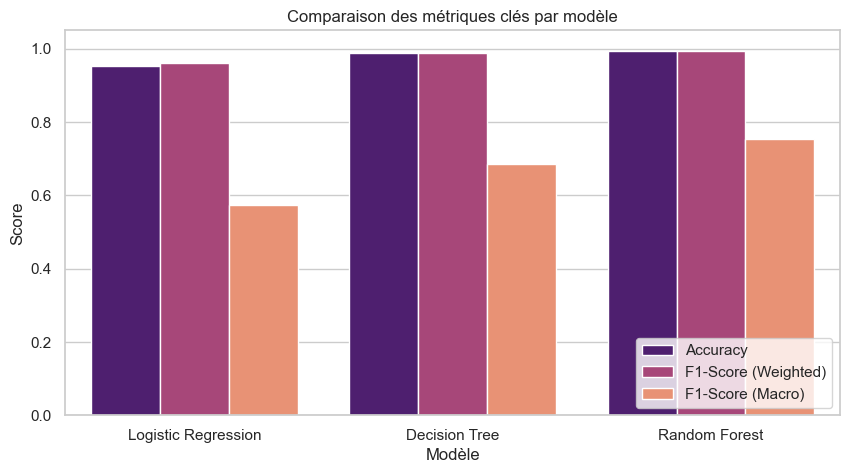

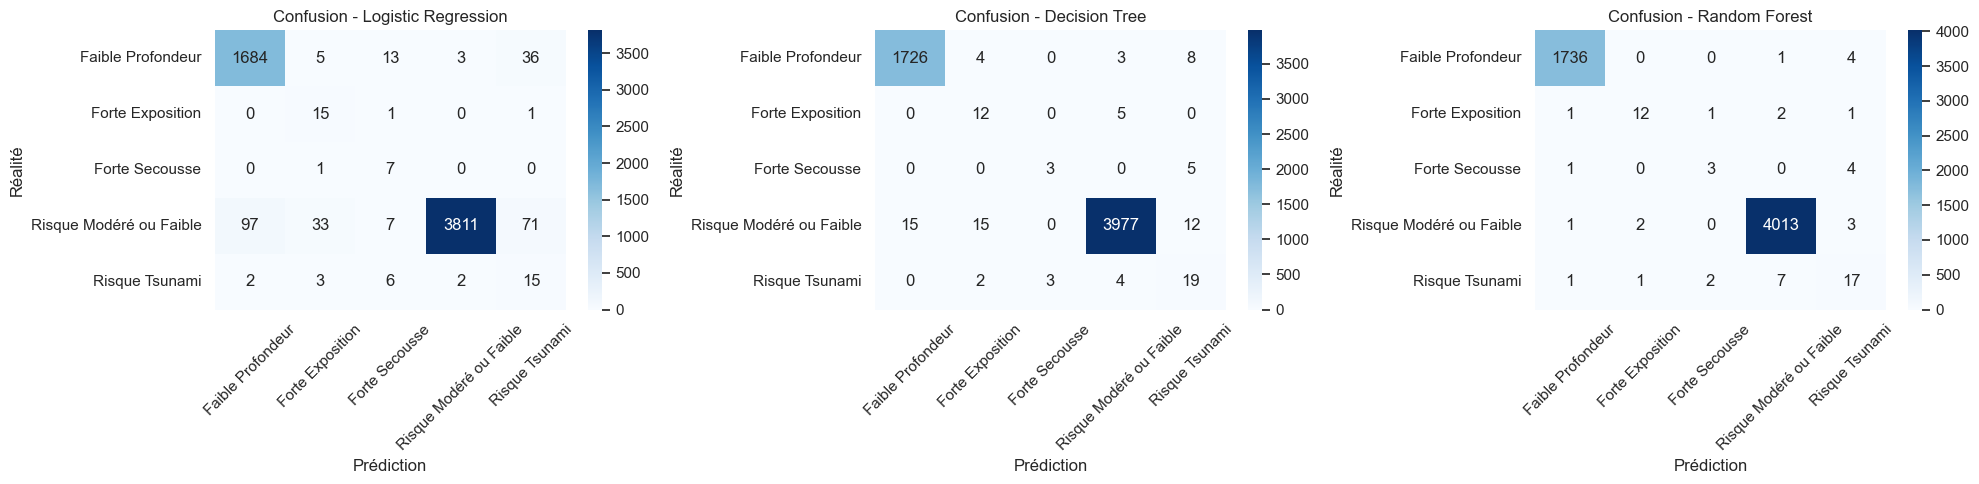

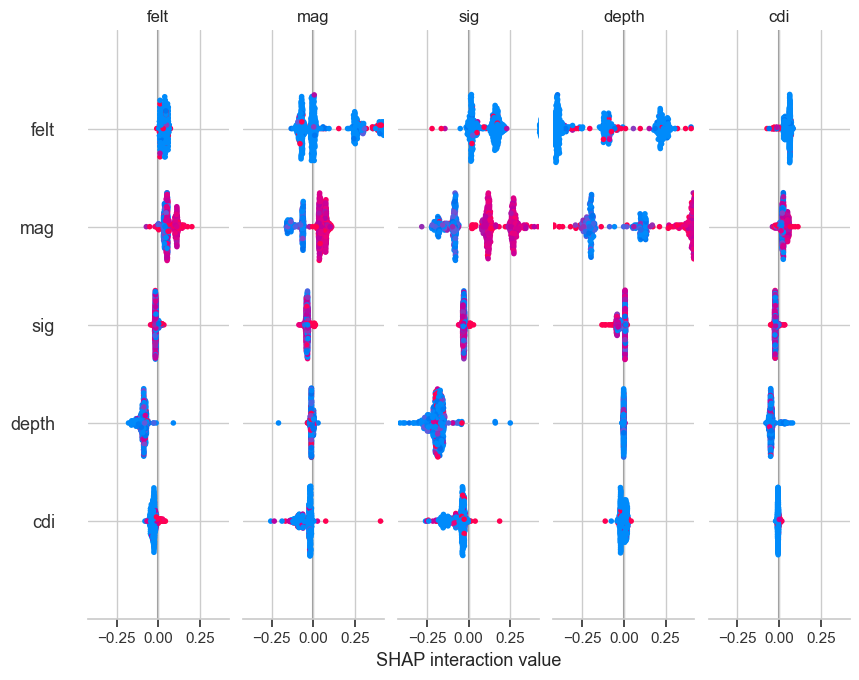

In [ ]:
# %% [markdown]
# # Classification & Comparaison de modèles avec Suivi MLflow - USGS Earthquakes
#
# Ce notebook compare 3 modèles de Machine Learning et enregistre les paramètres,
# métriques et datasets sur le serveur MLflow cible (`http://194.238.26.226:5000`).

# %%
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import shap

# --- Intégration MLflow ---
import mlflow
import mlflow.sklearn
from mlflow.data.pandas_dataset import PandasDataset

# Configuration du serveur de suivi MLflow
MLFLOW_TRACKING_URI = "http://194.238.26.226:5000"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("Risk_Classification_Model_4")

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# %% [markdown]
# ## 1. Chargement des données

# %%
file_path = os.path.join("data", "usgs_earthquakes_2025.csv")
df = pd.read_csv(file_path)

print(f"Dimension du dataset : {df.shape}")
df.head()

# %% [markdown]
# ## 2. Définition de la variable cible Y

# %%
def define_risk_category(row):
    # Priority 1: Risque Tsunami
    if row.get('tsunami') == 1:
        return 'Risque Tsunami'
    
    # Priority 2: Forte Secousse
    mag = row.get('mag', 0)
    mmi = row.get('mmi', 0)
    if (pd.notna(mag) and mag >= 6.5) or (pd.notna(mmi) and mmi >= 7.0):
        return 'Forte Secousse'
    
    # Priority 3: Forte Exposition
    alert = row.get('alert')
    felt = row.get('felt', 0)
    sig = row.get('sig', 0)
    if (alert in ['orange', 'red']) or (pd.notna(felt) and felt > 1000) or (pd.notna(sig) and sig > 600):
        return 'Forte Exposition'
    
    # Priority 4: Faible Profondeur
    depth = row.get('depth')
    if pd.notna(depth) and pd.notna(mag) and (depth <= 15) and (mag >= 4.0):
        return 'Faible Profondeur'
    
    # Priority 5: Défaut
    return 'Risque Modéré ou Faible'

# Application de la règle métier
df['target_risk_category'] = df.apply(define_risk_category, axis=1)

# %% [markdown]
# ## 3. Préparation des données & Normalisation

# %%
feature_cols_num = ['mag', 'depth', 'sig', 'felt', 'cdi', 'mmi', 'nst', 'dmin', 'rms', 'gap', 'latitude', 'longitude']
feature_cols_cat = ['alert', 'magType']

X = df[feature_cols_num + feature_cols_cat].copy()
y = df['target_risk_category']

# Imputation des valeurs manquantes
X['felt'] = X['felt'].fillna(0)
X['cdi'] = X['cdi'].fillna(0)
X['mmi'] = X['mmi'].fillna(0)

for col in ['nst', 'dmin', 'gap']:
    X[col] = X[col].fillna(X[col].median())

X['alert'] = X['alert'].fillna('none')
X['magType'] = X['magType'].fillna('unknown')

# Encodage catégorique
X = pd.get_dummies(X, columns=feature_cols_cat, drop_first=False)

# Split Stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation des variables numériques
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[feature_cols_num] = scaler.fit_transform(X_train[feature_cols_num])
X_test_scaled[feature_cols_num] = scaler.transform(X_test[feature_cols_num])

# %% [markdown]
# ## 4. Entraînement des modèles & Logging MLflow

# %%
# Création des objets Dataset pour MLflow
dataset_train_raw = mlflow.data.from_pandas(
    pd.concat([X_train, y_train], axis=1), 
    targets='target_risk_category', 
    name="USGS_Train_Raw"
)

dataset_train_scaled = mlflow.data.from_pandas(
    pd.concat([X_train_scaled, y_train], axis=1), 
    targets='target_risk_category', 
    name="USGS_Train_Scaled"
)

models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        "scaled": True,
        "dataset": dataset_train_scaled,
        "params": {"max_iter": 1000, "class_weight": "balanced", "solver": "lbfgs"}
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
        "scaled": False,
        "dataset": dataset_train_raw,
        "params": {"max_depth": 10, "class_weight": "balanced", "criterion": "gini"}
    },
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1),
        "scaled": False,
        "dataset": dataset_train_raw,
        "params": {"n_estimators": 100, "max_depth": 12, "class_weight": "balanced"}
    }
}

predictions = {}

for name, config in models.items():
    print(f"\n--- Entraînement et enregistrement MLflow : {name} ---")
    
    model = config["model"]
    is_scaled = config["scaled"]
    mlflow_dataset = config["dataset"]
    
    # Sélection des données appropriées
    X_tr = X_train_scaled if is_scaled else X_train
    X_te = X_test_scaled if is_scaled else X_test
    
    with mlflow.start_run(run_name=name):
        # 1. Log du Dataset
        mlflow.log_input(mlflow_dataset, context="training")
        
        # 2. Entraînement
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        predictions[name] = y_pred
        
        # 3. Calcul des Métriques
        acc = accuracy_score(y_test, y_pred)
        prec_w = precision_score(y_test, y_pred, average='weighted')
        rec_w = recall_score(y_test, y_pred, average='weighted')
        f1_w = f1_score(y_test, y_pred, average='weighted')
        f1_m = f1_score(y_test, y_pred, average='macro')
        
        # 4. Log des Paramètres
        mlflow.log_params(config["params"])
        mlflow.log_param("scaled_features", is_scaled)
        mlflow.log_param("num_features", X_tr.shape[1])
        mlflow.log_param("random_state", 42)
        
        # 5. Log des Métriques
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision_weighted", prec_w)
        mlflow.log_metric("recall_weighted", rec_w)
        mlflow.log_metric("f1_score_weighted", f1_w)
        mlflow.log_metric("f1_score_macro", f1_m)
        
        # 6. Log du Modèle dans l'artefact storage de MLflow
        mlflow.sklearn.log_model(model, artifact_path="model")
        
        print(f"[{name}] Logged successfully to MLflow (F1-Macro: {f1_m:.4f})")

# %% [markdown]
# ## 5. Comparaison des performances & Métriques

# %%
results = []

for name, y_pred in predictions.items():
    results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Weighted)": precision_score(y_test, y_pred, average='weighted'),
        "Recall (Weighted)": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score (Weighted)": f1_score(y_test, y_pred, average='weighted'),
        "F1-Score (Macro)": f1_score(y_test, y_pred, average='macro')
    })

df_results = pd.DataFrame(results)
print("\n=== TABLEAU COMPARATIF DES PERFORMANCES ===")
display(df_results.sort_values(by="F1-Score (Macro)", ascending=False))

# Visualisation des métriques
plt.figure(figsize=(10, 5))
df_results_melted = df_results.melt(id_vars="Modèle", value_vars=["Accuracy", "F1-Score (Weighted)", "F1-Score (Macro)"])
sns.barplot(data=df_results_melted, x="Modèle", y="value", hue="variable", palette="magma")
plt.title("Comparaison des métriques clés par modèle")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.show()

# %% [markdown]
# ## 6. Matrices de Confusion

# %%
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
labels = np.unique(y)

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=labels, yticklabels=labels)
    ax.set_title(f"Confusion - {name}")
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Réalité")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Interprétabilité SHAP (Random Forest - Meilleur Modèle)

# %%
best_model = models["Random Forest"]["model"]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test.iloc[:500])

shap.summary_plot(shap_values, X_test.iloc[:500], class_names=best_model.classes_)